In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv(r"C:\Users\Admin\Desktop\My stuff\Programming\ML\Projects\spotify-recommendation-system\data\processed\tracks_feature.csv")

In [3]:
#Select mood features
mood_features=['danceability','energy','valence','acousticness','tempo','loudness']

In [5]:
#Convert to matrix
X=df[mood_features].values
X

array([[0.68629442, 0.461     , 0.71859296, 0.03232932, 0.36124534,
        0.79139152],
       [0.42639594, 0.166     , 0.26834171, 0.92771084, 0.31839735,
        0.59737713],
       [0.44467005, 0.359     , 0.12060302, 0.21084337, 0.31364331,
        0.73612267],
       ...,
       [0.63857868, 0.329     , 0.74673367, 0.87048193, 0.54393274,
        0.71464773],
       [0.59593909, 0.506     , 0.41507538, 0.38253012, 0.55865095,
        0.71475871],
       [0.53401015, 0.487     , 0.71155779, 0.68373494, 0.32541952,
        0.72742911]])

In [8]:
inertias=[]
K_range=range(2,15)

for k in K_range:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

inertias


[15875.639418729432,
 12214.887464108975,
 10216.787571769511,
 9096.72777692429,
 8363.777328483236,
 7843.328419657999,
 7350.047087255915,
 6962.637020243557,
 6659.153328556922,
 6364.550228326165,
 6165.44710094721,
 5978.566502931263,
 5806.040427291277]

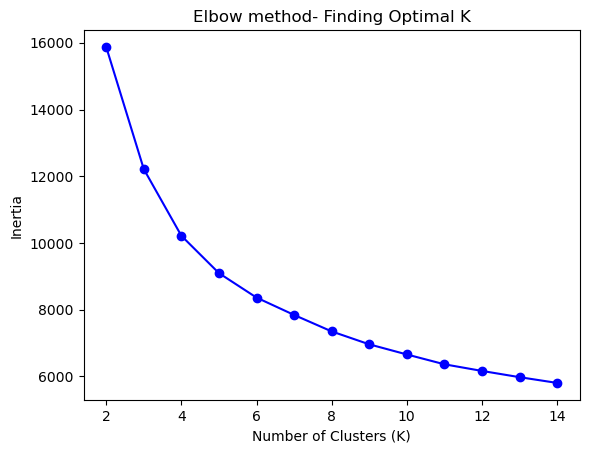

In [9]:
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow method- Finding Optimal K')
plt.show()

In [14]:
#As we can see, K=5 or K=6 is the best as the inertia reduces the most at these points

#Fit Final K means model
BEST_K=6
km_final=KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['mood_cluster']=km_final.fit_predict(X)

In [27]:
#Label clusters as moods
#Look at each cluster's centroid to name it

centroids = pd.DataFrame(km_final.cluster_centers_, columns=mood_features)
print(centroids)

mood_labels={
    0:'Sad',
    1:'Party',
    2:'Workout',
    3:'Chill',
    4:'Acoustic',
    5:'Focus'
}

df['mood']=df['mood_cluster'].map(mood_labels)


   danceability    energy   valence  acousticness     tempo  loudness
0      0.604811  0.552163  0.306509      0.186672  0.485404  0.754764
1      0.676660  0.785170  0.725246      0.094032  0.515996  0.802634
2      0.333088  0.164881  0.160482      0.899945  0.425095  0.563138
3      0.559704  0.395030  0.404817      0.760784  0.476192  0.715030
4      0.463363  0.883734  0.286570      0.031046  0.549565  0.815011
5      0.660435  0.638191  0.756302      0.573327  0.498541  0.772908


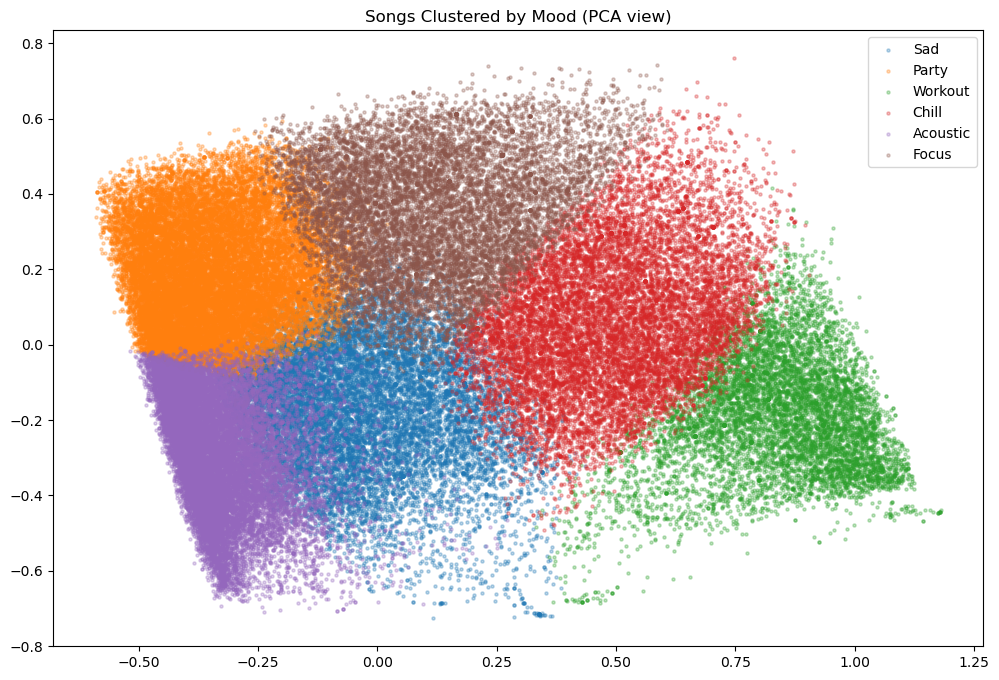

In [28]:
#Visualize with PCA
# Concept: PCA reduces 6 dimensions → 2 so we can plot it
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
for mood_id, mood_name in mood_labels.items():
    mask = df['mood_cluster'] == mood_id
    plt.scatter(coords[mask, 0], coords[mask, 1], label=mood_name, alpha=0.3, s=5)

plt.legend()
plt.title('Songs Clustered by Mood (PCA view)')
plt.show()


In [29]:
#Save model with enriched Dataframe
import pickle
with open(r"C:\Users\Admin\Desktop\My stuff\Programming\ML\Projects\spotify-recommendation-system\models\kmeans_mood.pkl", 'wb') as f:
    pickle.dump(km_final,f)

df.to_csv(r"C:\Users\Admin\Desktop\My stuff\Programming\ML\Projects\spotify-recommendation-system\data\processed\tracks_with_moods.csv", index= False)